#Import libraries

In [65]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Data cleaning

# 1. Loading dataset

In [2]:
df = pd.read_csv('atm_logs_2025.csv', encoding='utf-8-sig', low_memory=False)

print(f"Amount of records: {len(df)}")

Amount of records: 53040


In [3]:
print("\nFirst 5 records:")
df.head()


First 5 records:


,timestamp,atm_id,address,location_type,working_hours,error_code,error_category,error_message,duration_sec,auto_recovered,severity
0,2025-03-14 17:10:20,31637,"АБЫЛАЙ ХАНА, 29",Отделение банка,Круглосуточно,E203,Software,OS update failed,2600.0,False,High
1,2025-06-28 01:05:46,33947,"ЕСЕТ БАТЫРА, 25",ТД,До 21:00,E003,Cash,Invalid banknote detected,707.0,False,Medium
2,2025-07-06 02:22:21,32408,"АБЫЛАЙ ХАНА, 29",Отделение банка,Круглосуточно,E102,Hardware,Dispenser jam,3137.0,False,High
3,2025-10-17 16:20:46,33473,"ШОССЕ АЛАШ, 15",Рынок,До 20:00,E001,Cash,Out of cash,3028.0,False,High
4,2025-01-17 23:57:39,33003,"АЛЬ-ФАРАБИ, 30/3",Магазин,Закрыто,E001,Cash,Out of cash,3096.0,False,High


In [4]:
print("\nData types:")
print(df.dtypes)


Data types:
timestamp          object
atm_id              int64
address            object
location_type      object
working_hours      object
error_code         object
error_category     object
error_message      object
duration_sec      float64
auto_recovered     object
severity           object
dtype: object


In [5]:
print("\nAmount of missed values:")
print(df.isnull().sum())


Amount of missed values:
timestamp            0
atm_id               0
address              0
location_type        0
working_hours        0
error_code        1060
error_category       0
error_message     1184
duration_sec      1147
auto_recovered       0
severity             0
dtype: int64


# 2. CLEARING TIMESTAMPS

In [7]:
def clean_timestamp(ts):
    """Converts different date formats into a single datetime"""
    if pd.isna(ts):
        return np.nan
    ts_str = str(ts).strip()
    try:
        # If it contains '/', then the format is DD/MM/YYYY HH:MM
        if '/' in ts_str:
            return pd.to_datetime(ts_str, format='%d/%m/%Y %H:%M', errors='coerce')
        else:
            # Standard format YYYY-MM-DD HH:MM:SS
            return pd.to_datetime(ts_str, format='%Y-%m-%d %H:%M:%S', errors='coerce')
    except:
        return np.nan

df['timestamp'] = df['timestamp'].apply(clean_timestamp)

# Delete records where the timestamp could not be converted
invalid_ts_count = df['timestamp'].isna().sum()
if invalid_ts_count > 0:
    df = df.dropna(subset=['timestamp'])

## 3. DUPLICATE REMOVAL

In [9]:
# Count duplicates by key fields (time stamp ± 5 seconds, ATM, error code)
# Hard duplicates first (exact match)

duplicates_before = len(df)
df = df.drop_duplicates(subset=['atm_id', 'timestamp', 'error_code', 'address'], keep='first')
print(f"Exact duplicates removed: {duplicates_before - len(df)}")

Exact duplicates removed: 0


In [10]:
# Soft duplicates (almost identical in time + ATM + error)
# Sort by time, group, and delete similar ones within 5 seconds

df = df.sort_values('timestamp').reset_index(drop=True)
df['timestamp_floor'] = df['timestamp'].dt.floor('5S')  # round to 5 sec
soft_dupes_before = len(df)
df = df.drop_duplicates(subset=['atm_id', 'timestamp_floor', 'error_code'], keep='first')
df = df.drop(columns=['timestamp_floor'])
print(f"Soft duplicates removed (within 5 sec): {soft_dupes_before - len(df)}")

Soft duplicates removed (within 5 sec): 235


/tmp/ipykernel_3081/355691091.py:5: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['timestamp_floor'] = df['timestamp'].dt.floor('5S')  # round to 5 sec


# 4. CLEANING ERROR_CODE (REPLACING INVALID CODES)

In [12]:
# Acceptable error codes
VALID_ERROR_CODES = ['E001', 'E002', 'E003', 'E045', 'E046', 'E047',
                     'E102', 'E103', 'E104', 'E105', 'E203', 'E204',
                     'E205', 'E301', 'E302']

# Функция очистки кода ошибки
def clean_error_code(code):
    if pd.isna(code):
        return 'Unknown'
    code_str = str(code).strip().upper()
    if code_str in VALID_ERROR_CODES:
        return code_str
    else:
        return 'Unknown'

df['error_code'] = df['error_code'].apply(clean_error_code)


# 5. Filling in the gaps in ERROR_CATEGORY and ERROR_MESSAGE

In [13]:
# Dictionary for mapping codes into categories and messages
ERROR_MAP = {
    'E001': {'category': 'Cash', 'msg': 'Out of cash'},
    'E002': {'category': 'Cash', 'msg': 'Cash cassette jam'},
    'E003': {'category': 'Cash', 'msg': 'Invalid banknote detected'},
    'E045': {'category': 'Communication', 'msg': 'GPRS connection timeout'},
    'E046': {'category': 'Communication', 'msg': 'Network unreachable'},
    'E047': {'category': 'Communication', 'msg': 'SSL handshake failed'},
    'E102': {'category': 'Hardware', 'msg': 'Dispenser jam'},
    'E103': {'category': 'Hardware', 'msg': 'Card reader motor failure'},
    'E104': {'category': 'Hardware', 'msg': 'Printer thermal head error'},
    'E105': {'category': 'Hardware', 'msg': 'Power supply fluctuation'},
    'E203': {'category': 'Software', 'msg': 'OS update failed'},
    'E204': {'category': 'Software', 'msg': 'App crash on startup'},
    'E205': {'category': 'Software', 'msg': 'Database connection error'},
    'E301': {'category': 'Security', 'msg': 'Tamper detection alert'},
    'E302': {'category': 'Security', 'msg': 'PIN pad error'},
    'Unknown': {'category': 'Unknown', 'msg': 'Unknown error'},
}

# Fill in error_category
df['error_category'] = df.apply(
    lambda row: ERROR_MAP.get(row['error_code'], ERROR_MAP['Unknown'])['category']
    if pd.isna(row['error_category']) or row['error_category'] == 'Unknown'
    else row['error_category'],
    axis=1
)

# Fill in error_message (if empty or NaN)
def clean_message(row):
    if pd.isna(row['error_message']) or str(row['error_message']).strip() == '':
        return ERROR_MAP.get(row['error_code'], ERROR_MAP['Unknown'])['msg']
    return str(row['error_message']).strip()

df['error_message'] = df.apply(clean_message, axis=1)

# 6. CLEANING DURATION_SEC (NON-NEGATIVE NUMBERS)

In [14]:
# Convert to a numeric type
df['duration_sec'] = pd.to_numeric(df['duration_sec'], errors='coerce')

# Negative values ​​-> take the absolute value
negative_count = (df['duration_sec'] < 0).sum()
if negative_count > 0:
    print(f"Corrected negative values: {negative_count}")
    df['duration_sec'] = df['duration_sec'].abs()

# Gaps fill with median
null_duration = df['duration_sec'].isna().sum()
if null_duration > 0:
    median_duration = df['duration_sec'].median()
    print(f"Filled gaps in duration_sec: {null_duration} (median = {median_duration:.0f} sec)")
    df['duration_sec'] = df['duration_sec'].fillna(median_duration)

df['duration_sec'] = df['duration_sec'].astype(int)

Corrected negative values: 109
Filled gaps in duration_sec: 1145 (median = 1334 sec)


# 7. STANDARDIZATION OF SEVERITY COLUMN

In [15]:
VALID_SEVERITY = ['Critical', 'High', 'Medium', 'Low', 'Unknown']

def clean_severity(sev):
    if pd.isna(sev):
        return 'Unknown'
    sev_str = str(sev).strip().lower()

    # Mapping typos and variants
    if sev_str in ['critical', 'crit', 'c']:
        return 'Critical'
    elif sev_str in ['high', 'h', 'major']:
        return 'High'
    elif sev_str in ['medium', 'med', 'm']:
        return 'Medium'
    elif sev_str in ['low', 'l']:
        return 'Low'
    else:
        return 'Unknown'

df['severity'] = df['severity'].apply(clean_severity)

# 8. STANDARDIZING AUTO_RECOVERED (CAST TO BOOLEAN)

In [16]:
def clean_auto_recovered(val):
    if pd.isna(val):
        return False
    val_str = str(val).strip().upper()

    if val_str in ['TRUE', 'T', '1', 'YES', 'Y']:
        return True

    elif val_str in ['FALSE', 'F', '0', 'NO', 'N']:
        return False

    elif isinstance(val, bool):
        return val
    else:
        return False

df['auto_recovered'] = df['auto_recovered'].apply(clean_auto_recovered)

# 9. CREATION OF NEW FEATURES (FOR ANALYSIS)

In [18]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

df['date'] = df['timestamp'].dt.date
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()
df['month'] = df['timestamp'].dt.month
df['year'] = df['timestamp'].dt.year

# 10. FINAL STATISTICS AND SAVING

In [22]:
print(f"Total number of records: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

print("\nChecking for gaps AFTER cleaning:")
print(df[['timestamp', 'atm_id', 'error_code', 'duration_sec', 'severity', 'auto_recovered']].isnull().sum())

print("\nSeverity statistics:")
print(df['severity'].value_counts())

print("\nStatistics for error_category:")
print(df['error_category'].value_counts())

print("\nExample of cleaned data (first 5 rows):")
print(df.head())

Total number of records: 52805
Columns: ['timestamp', 'date', 'hour', 'day_of_week', 'month', 'year', 'atm_id', 'address', 'location_type', 'working_hours', 'error_code', 'error_category', 'error_message', 'duration_sec', 'auto_recovered', 'severity']

Checking for gaps AFTER cleaning:
timestamp         0
atm_id            0
error_code        0
duration_sec      0
severity          0
auto_recovered    0
dtype: int64

Severity statistics:
severity
High        30949
Medium      15030
Critical     5549
Low          1061
Unknown       216
Name: count, dtype: int64

Statistics for error_category:
error_category
Cash             18543
Communication    10568
Hardware         10476
Software          7916
Security          5203
Unknown             99
Name: count, dtype: int64

Example of cleaned data (first 5 rows):
            timestamp        date  hour day_of_week  month  year atm_id  \
0 2025-01-01 00:03:31  2025-01-01     0   Wednesday      1  2025  33939   
1 2025-01-01 01:22:54  2025-01-

In [21]:
#rearrange the columns for convenience
column_order = [
    'timestamp', 'date', 'hour', 'day_of_week', 'month', 'year',
    'atm_id', 'address', 'location_type', 'working_hours',
    'error_code', 'error_category', 'error_message',
    'duration_sec', 'auto_recovered', 'severity'
]
df = df[column_order]

# saving
df.to_csv('atm_logs_clean_2025.csv', index=False, encoding='utf-8-sig')

---
# Statistical analysis

## 1. DESCRIPTIVE STATISTICS

In [25]:
df = pd.read_csv('atm_logs_clean_2025.csv', encoding='utf-8-sig', parse_dates=['timestamp', 'date'])

In [26]:
print(f"Total incidents: {len(df)}")
print(f"Unique ATMs: {df['atm_id'].nunique()}")
print(f"Period: from {df['date'].min()} to {df['date'].max()}")

Total incidents: 52805
Unique ATMs: 149
Period: from 2025-01-01 00:00:00 to 2025-12-31 00:00:00


In [30]:
print("\n--- Recovery time (duration_sec) ---")
print(df['duration_sec'].describe())

print(f"\nAverage recovery time (min): {df['duration_sec'].mean()/60:.1f}")
print(f"Median recovery time (min): {df['duration_sec'].median()/60:.1f}")

print("\n--- Auto-recovery ---")
auto_recovery_rate = df['auto_recovered'].mean() * 100
print(f"Auto-recovery rate: {auto_recovery_rate:.1f}%")


--- Recovery time (duration_sec) ---
count    52805.000000
mean      1768.034107
std       1403.885604
min          0.000000
25%        695.000000
50%       1334.000000
75%       2633.000000
max       7199.000000
Name: duration_sec, dtype: float64

Average recovery time (min): 29.5
Median recovery time (min): 22.2

--- Auto-recovery ---
Auto-recovery rate: 40.1%


In [32]:
print("\n--- Distribution by criticality ---")
print(df['severity'].value_counts())
print(df['severity'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')


--- Distribution by criticality ---
severity
High        30949
Medium      15030
Critical     5549
Low          1061
Unknown       216
Name: count, dtype: int64
severity
High        58.6%
Medium      28.5%
Critical    10.5%
Low          2.0%
Unknown      0.4%
Name: proportion, dtype: object


## 2. FREQUENCY ERROR ANALYSIS

In [33]:
# Top 10 Code Errors
print("\n--- Top 10 Code Errors ---")
top_errors = df['error_code'].value_counts().head(10)
print(top_errors)


--- Top 10 Code Errors ---
error_code
E001    14453
E045     7784
E102     6142
E203     4134
E301     2572
E302     2532
E003     2140
E103     2082
E205     2035
E046     1585
Name: count, dtype: int64


In [34]:
# Топ-5 категорий
print("\n--- # Top 5 error categories ---")
print(df['error_category'].value_counts().head(5))


--- # Top 5 error categories ---
error_category
Cash             18543
Communication    10568
Hardware         10476
Software          7916
Security          5203
Name: count, dtype: int64


In [38]:
# Top 10 Problem ATMs
print("\n--- Top 10 Problem ATMs ---")
top_atm = df['atm_id'].value_counts().head(10)
print(top_atm)


--- Top 10 Problem ATMs ---
atm_id
33927    685
32439    684
33846    682
36776    673
33829    666
33939    663
33489    662
30235    661
32406    659
32409    658
Name: count, dtype: int64


In [40]:
# Top 10 locations for crashes
print("\n--- Top 10 locations for crashes ---")
print(df['location_type'].value_counts().head(10))


--- Top 10 locations for crashes ---
location_type
Отделение банка    18963
Магазин             9457
ТД                  8342
ТРЦ                 6343
Поликлиника         1563
Университет         1255
БЦ                  1207
Рынок                952
МФЦА                 661
Кафе                 645
Name: count, dtype: int64


## Visualization

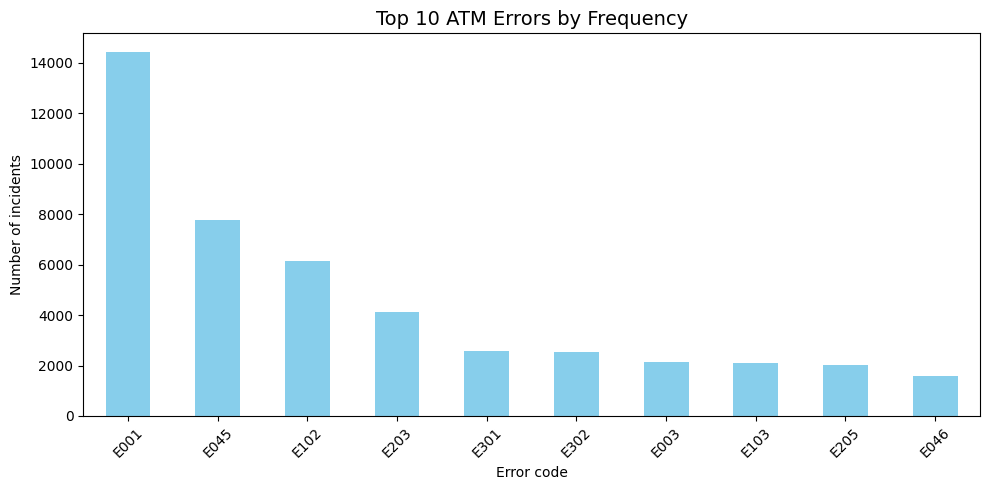

In [44]:
# Histogram of top 10 errors
plt.figure(figsize=(10, 5))
top_errors.plot(kind='bar', color='skyblue')
plt.title('Top 10 ATM Errors by Frequency', fontsize=14)
plt.xlabel('Error code')
plt.ylabel('Number of incidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_errors.png')
plt.show()

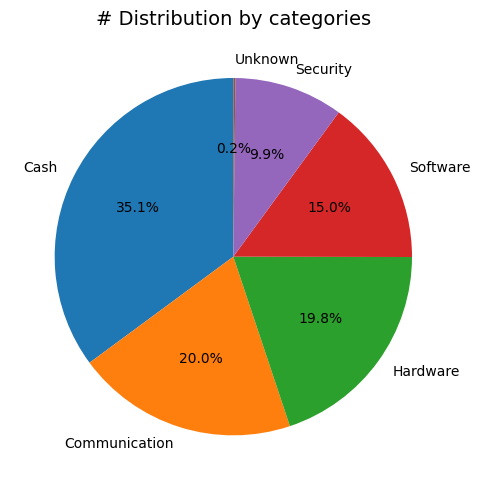

In [45]:
# Distribution by categories
plt.figure(figsize=(5, 5))
df['error_category'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('# Distribution by categories', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.savefig('category_pie.png')
plt.show()

## 3. TIME ANALYSIS

In [46]:
# By the hour
print("\n---Top 5 hours with the most crashes ---")
hourly = df['hour'].value_counts().sort_index()
print(hourly.head(5))
print(hourly.tail(5))

# By day of the week
print("\n--- By day of the week ---")
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily = df['day_of_week'].value_counts().reindex(day_order)
print(daily)

# By month
print("\n--- By month ---")
monthly = df['month'].value_counts().sort_index()
print(monthly)


---Top 5 hours with the most crashes ---
hour
0    890
1    870
2    860
3    906
4    871
Name: count, dtype: int64
hour
19    3814
20    3718
21     886
22     918
23     839
Name: count, dtype: int64

--- By day of the week ---
day_of_week
Monday       7582
Tuesday      7359
Wednesday    7621
Thursday     7536
Friday       7625
Saturday     7658
Sunday       7424
Name: count, dtype: int64

--- By month ---
month
1     4420
2     4030
3     4480
4     4374
5     4475
6     4260
7     4358
8     4498
9     4419
10    4560
11    4460
12    4471
Name: count, dtype: int64


##  Heatmap: Hour × Day of Week

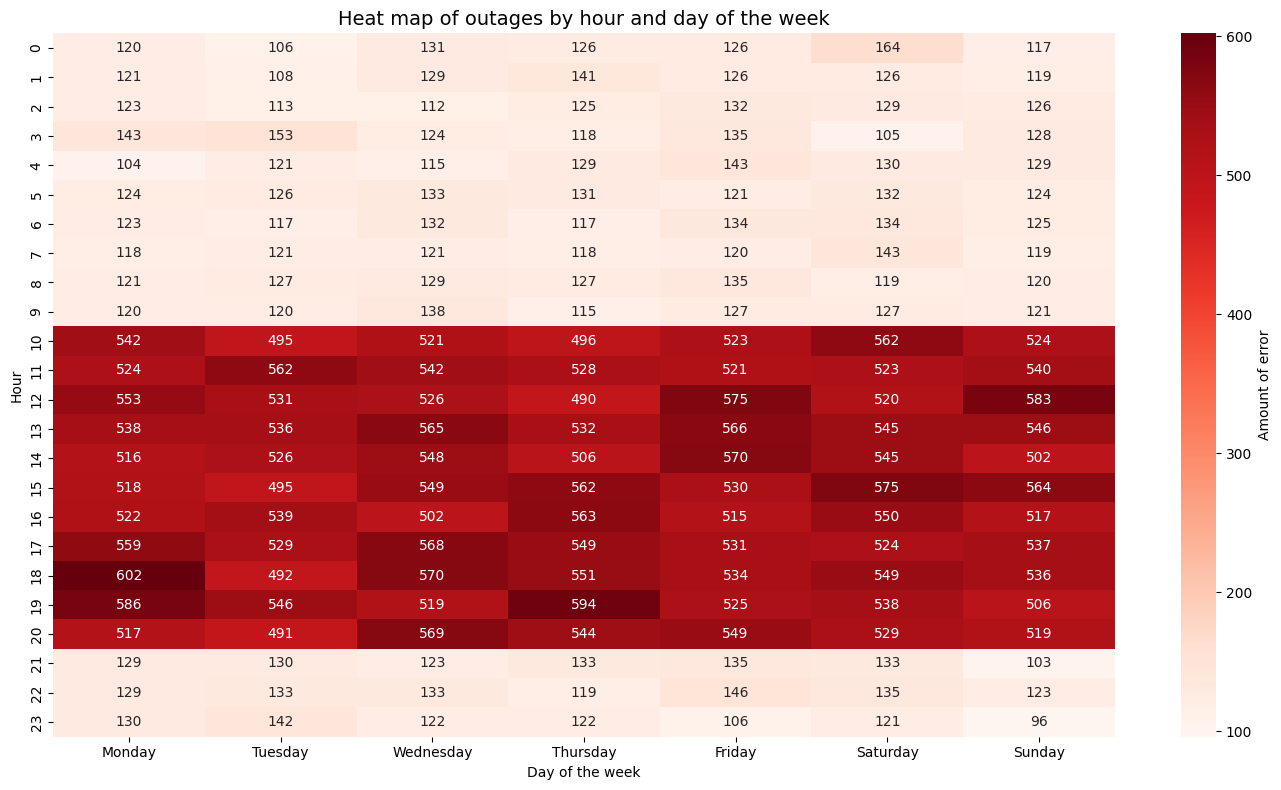

In [47]:
pivot_table = df.pivot_table(
    index='hour',
    columns='day_of_week',
    values='error_code',
    aggfunc='count',
    fill_value=0
)

pivot_table = pivot_table[day_order]

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, cmap='Reds', annot=True, fmt='d', cbar_kws={'label': 'Amount of error'})
plt.title('Heat map of outages by hour and day of the week', fontsize=14)
plt.xlabel('Day of the week')
plt.ylabel('Hour')
plt.tight_layout()
plt.savefig('heatmap.png')
plt.show()

## 4. RECOVERY TIME ANALYSIS

In [49]:
# By error category
print("\n--- Average recovery time by category ---")
mttr_category = df.groupby('error_category')['duration_sec'].mean().sort_values(ascending=False)
print((mttr_category / 60).round(1).astype(str) + ' min')

# By severity
print("\n--- Mean time to recovery by criticality ---")
mttr_severity = df.groupby('severity')['duration_sec'].mean().sort_values(ascending=False)
print((mttr_severity / 60).round(1).astype(str) + ' min')


--- Average recovery time by category ---
error_category
Security         53.7 min
Software         34.7 min
Cash             29.6 min
Hardware         28.8 min
Unknown          25.4 min
Communication    14.1 min
Name: duration_sec, dtype: object

--- Mean time to recovery by criticality ---
severity
Critical    70.6 min
High        32.1 min
Unknown     25.3 min
Medium      10.8 min
Low          2.7 min
Name: duration_sec, dtype: object


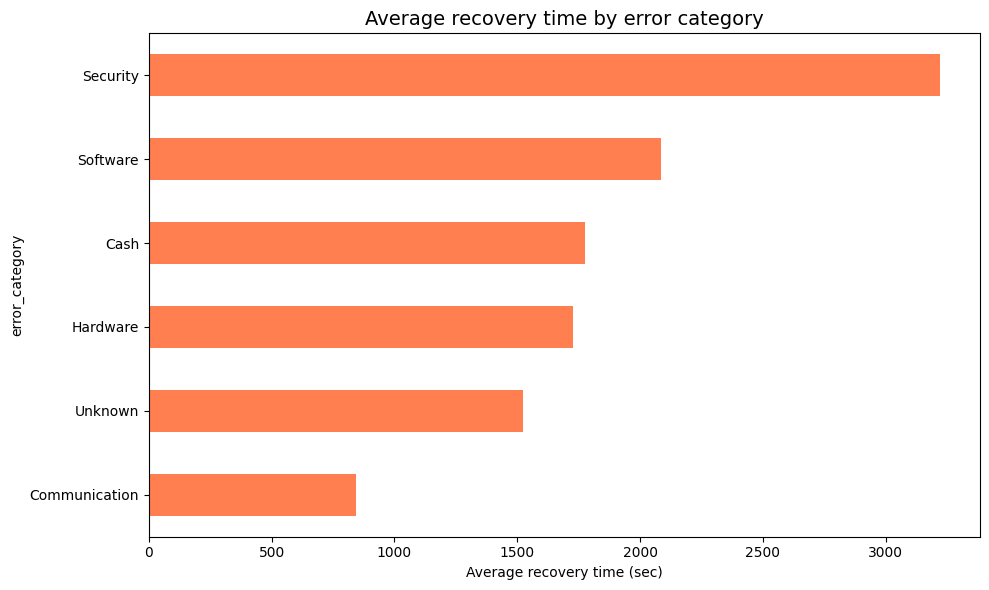

In [50]:
# MTTR bar chart by category
plt.figure(figsize=(10, 6))
mttr_category.sort_values(ascending=True).plot(kind='barh', color='coral')
plt.title('Average recovery time by error category', fontsize=14)
plt.xlabel('Average recovery time (sec)')
plt.tight_layout()
plt.savefig('mttr_category.png')
plt.show()

# Predictive modeling

# 1. FORECAST OF THE NUMBER OF DISASTER PER WEEK ( Prophet)

In [53]:
# PREDICTIVE MODELING - PROPHET FORECAST

df_daily = df.groupby('date').size().reset_index(name='failures')
df_daily.columns = ['ds', 'y']

print(f"Data for {len(df_daily)} days")

# Split into train (January-November) and test (December)
train = df_daily[df_daily['ds'] < '2025-12-01']
test = df_daily[df_daily['ds'] >= '2025-12-01']

print(f"Train: {len(train)} days (January-November)")
print(f"Test: {len(test)} days (December)")

Data for 365 days
Train: 334 days (January-November)
Test: 31 days (December)


In [54]:
# train model PROPHET

model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
    seasonality_prior_scale=10.0,
)

model.fit(train)

In [55]:
# DECEMBER FORECAST (31 days)
future = model.make_future_dataframe(periods=31)
forecast = model.predict(future)

In [59]:
# ACCURACY ASSESSMENT

# take the forecast only for December
forecast_dec = forecast[forecast['ds'] >= '2025-12-01']
forecast_dec = forecast_dec[forecast_dec['ds'] <= '2025-12-31']

# Compare with actual data
test_actual = test.set_index('ds')['y']
test_pred = forecast_dec.set_index('ds')['yhat']

common_dates = test_actual.index.intersection(test_pred.index)
test_actual_aligned = test_actual.loc[common_dates]
test_pred_aligned = test_pred.loc[common_dates]

mae = mean_absolute_error(test_actual_aligned, test_pred_aligned)
rmse = np.sqrt(mean_squared_error(test_actual_aligned, test_pred_aligned))

print(f"MAE (mean absolute error): {mae:.2f} errors per day")
print(f"RMSE (root mean square error): {rmse:.2f}")

MAE (mean absolute error): 10.89 errors per day
RMSE (root mean square error): 12.69


In [60]:
print(f"\nForecast for the first 7 days of December:")
for i in range(7):
    date = forecast_dec.iloc[i]['ds'].strftime('%Y-%m-%d')
    pred = forecast_dec.iloc[i]['yhat']
    lower = forecast_dec.iloc[i]['yhat_lower']
    upper = forecast_dec.iloc[i]['yhat_upper']
    actual = test_actual[date] if date in test_actual.index else 'no data'
    print(f"  {date}: prediction {pred:.1f} (range {lower:.1f}–{upper:.1f}), actually: {actual}")


Forecast for the first 7 days of December:
  2025-12-01: prediction 149.3 (range 134.7–162.7), actually: 138
  2025-12-02: prediction 146.4 (range 132.6–160.7), actually: 133
  2025-12-03: prediction 147.4 (range 133.6–160.1), actually: 161
  2025-12-04: prediction 148.6 (range 134.1–162.8), actually: 150
  2025-12-05: prediction 151.9 (range 137.8–166.0), actually: 130
  2025-12-06: prediction 151.2 (range 136.4–165.9), actually: 155
  2025-12-07: prediction 147.9 (range 133.9–162.5), actually: 128


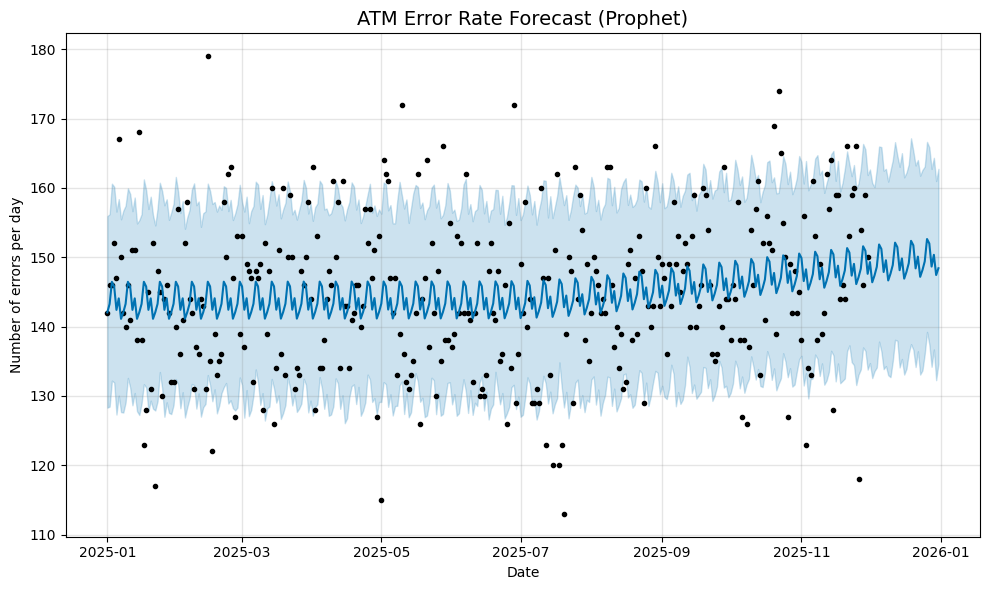

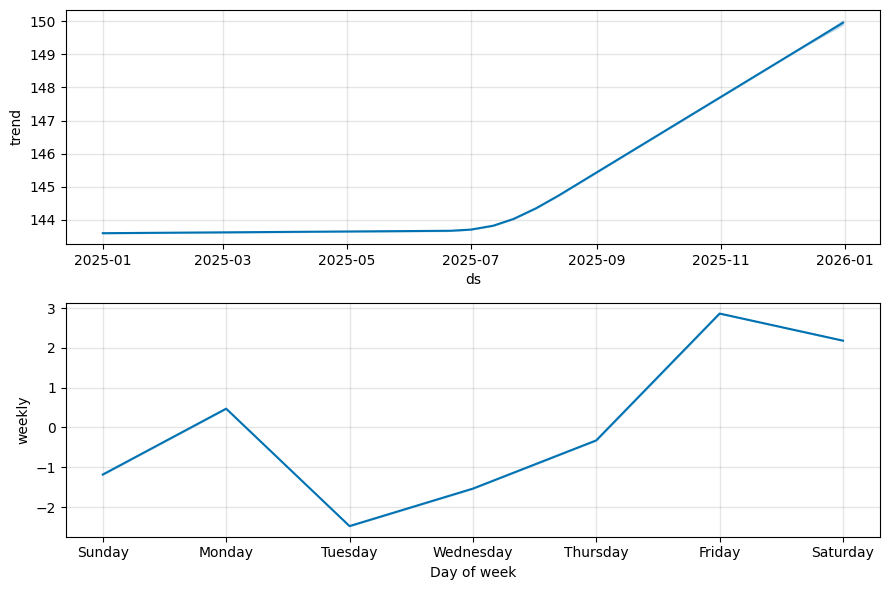

In [58]:
# Visualization

fig1 = model.plot(forecast)
plt.title('ATM Error Rate Forecast (Prophet)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Number of errors per day')
plt.tight_layout()
plt.savefig('prophet_forecast.png')
plt.show()

fig2 = model.plot_components(forecast)
plt.savefig('prophet_components.png')
plt.show()

## 2. CLASSIFICATION - PREDICTION AUTO_RECOVERED

In [62]:
# Data Preparation
# Selecting Features
features = ['error_category', 'severity', 'hour', 'day_of_week', 'location_type']
df_ml = df[features + ['auto_recovered']].copy()

# Transform categorical features
le_dict = {}
for col in ['error_category', 'severity', 'day_of_week', 'location_type']:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    le_dict[col] = le

# features and target
X = df_ml[features]
y = df_ml['auto_recovered'].astype(int)

# Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Size of train: {len(X_train)}, test: {len(X_test)}")
print(f"Balance of classes in y: {y.mean():.2%} auto-recoveries")

Size of train: 42244, test: 10561
Balance of classes in y: 40.06% auto-recoveries


Accuracy: 0.5904
ROC-AUC: 0.5050

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.99      0.74      6242
           1       0.46      0.01      0.02      4319

    accuracy                           0.59     10561
   macro avg       0.53      0.50      0.38     10561
weighted avg       0.54      0.59      0.45     10561



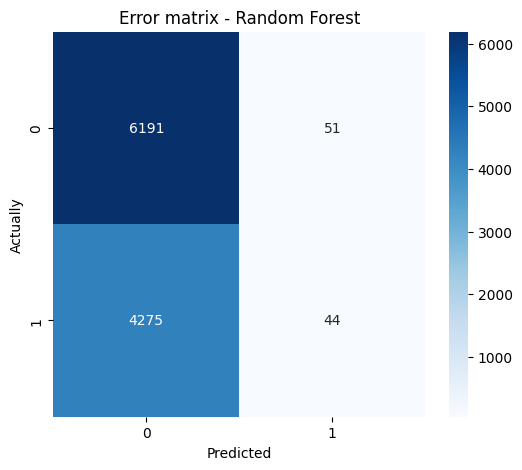


Importance of features:
          feature  importance
2            hour    0.319732
4   location_type    0.264529
3     day_of_week    0.175814
0  error_category    0.141327
1        severity    0.098599


In [64]:
# RANDOM FOREST classifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
y_pred_proba = rf.predict_proba(X_test)[:, 1]

print(f"Accuracy: {rf.score(X_test, y_test):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Error matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Error matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actually')
plt.savefig('confusion_matrix.png')
plt.show()

# Importance of features:
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nImportance of features:")
print(feature_importance)

## 3. CLUSTERING - ATM SEGMENTATION

In [66]:
# Aggregating data on ATMs
atm_features = df.groupby('atm_id').agg({
    'error_code': 'count',                    # failure rate
    'duration_sec': 'mean',                  # average recovery time
    'auto_recovered': 'mean',                # % auto-recoveries
    'severity': lambda x: (x == 'Critical').mean(),  # % critical
}).reset_index()

atm_features.columns = ['atm_id', 'total_failures', 'avg_duration', 'auto_recovery_rate', 'critical_rate']

print(f"Amount of ATM: {len(atm_features)}")

Amount of ATM: 149


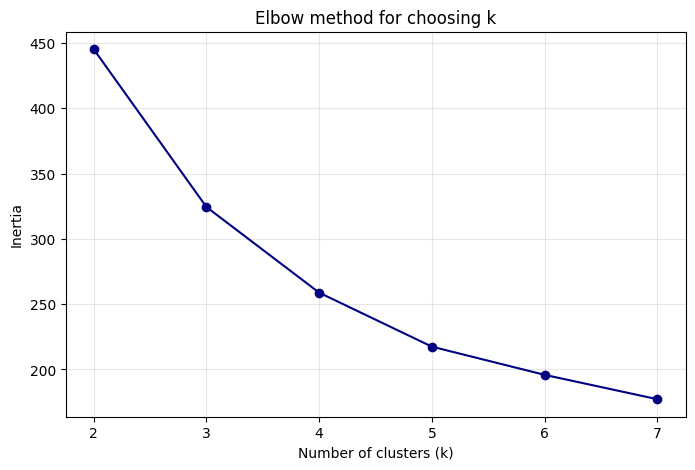


Distribution by clusters:
cluster
0    39
1    40
2    30
3    40
Name: count, dtype: int64


In [69]:
# Standartize
features_for_cluster = ['total_failures', 'avg_duration', 'auto_recovery_rate', 'critical_rate']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(atm_features[features_for_cluster])

# Selecting the optimal number of clusters (Elbow)
inertias = []
K_range = range(2, 8)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'o-', color='navy')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow method for choosing k')
plt.grid(alpha=0.3)
plt.savefig('elbow_method.png')
plt.show()

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
atm_features['cluster'] = kmeans.fit_predict(X_scaled)

print("\nDistribution by clusters:")
print(atm_features['cluster'].value_counts().sort_index())




Average characteristics by cluster:
         total_failures  avg_duration  auto_recovery_rate  critical_rate
cluster                                                                 
0             267.74359   1668.021306            0.403396       0.086959
1             295.50000   1809.148520            0.373028       0.114249
2             641.40000   1765.090735            0.401194       0.104113
3             282.52500   1822.908626            0.425816       0.113919


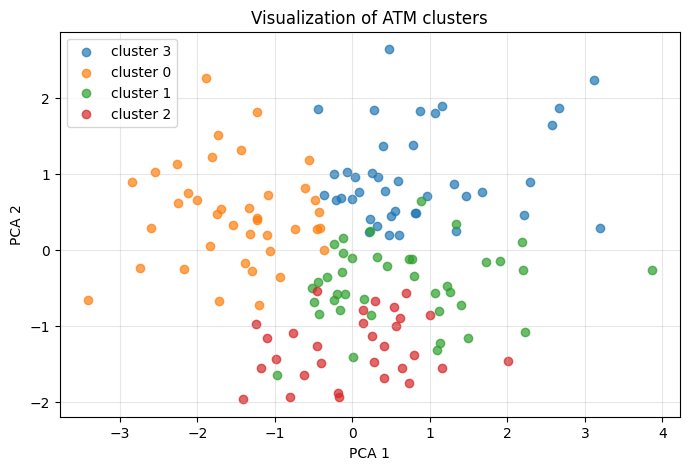

In [71]:
# Characteristics of clusters
cluster_summary = atm_features.groupby('cluster')[features_for_cluster].mean()
print("\nAverage characteristics by cluster:")
print(cluster_summary)

# Visualization of ATM clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
atm_features['pca1'] = X_pca[:, 0]
atm_features['pca2'] = X_pca[:, 1]

plt.figure(figsize=(8, 5))
for cluster in atm_features['cluster'].unique():
    subset = atm_features[atm_features['cluster'] == cluster]
    plt.scatter(subset['pca1'], subset['pca2'], label=f'cluster {cluster}', alpha=0.7)
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('Visualization of ATM clusters')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('clusters_pca.png')
plt.show()

In [73]:
#Interpretaions of clusters
for cluster in sorted(atm_features['cluster'].unique()):
    data = atm_features[atm_features['cluster'] == cluster]
    print(f"\nCluster {cluster} ({len(data)} ATMs):")
    print(f"  - Average number of failures: {data['total_failures'].mean():.1f}")
    print(f"  - Average recovery time: {data['avg_duration'].mean():.0f} сек")
    print(f"  - % auto-recoveries: {data['auto_recovery_rate'].mean():.2%}")
    print(f"  - % critical failures: {data['critical_rate'].mean():.2%}")


Cluster 0 (39 ATMs):
  - Average number of failures: 267.7
  - Average recovery time: 1668 сек
  - % auto-recoveries: 40.34%
  - % critical failures: 8.70%

Cluster 1 (40 ATMs):
  - Average number of failures: 295.5
  - Average recovery time: 1809 сек
  - % auto-recoveries: 37.30%
  - % critical failures: 11.42%

Cluster 2 (30 ATMs):
  - Average number of failures: 641.4
  - Average recovery time: 1765 сек
  - % auto-recoveries: 40.12%
  - % critical failures: 10.41%

Cluster 3 (40 ATMs):
  - Average number of failures: 282.5
  - Average recovery time: 1823 сек
  - % auto-recoveries: 42.58%
  - % critical failures: 11.39%
